# Machine Learning Exercise 2: Classification Basics

In this exercise, you'll be working with a dataset containing information about passengers on the Titanic. You can get more information about this dataset [here](https://www.kaggle.com/competitions/titanic). Our goal will be to build a model to predict whether a passenger survived the voyage.

Let's start by building a model using Age as a predictor variable.

When performing a train/test split, you usually want to make sure that the ratios of target values look the same in the training set and in the test set. This is especially true with imbalanced targets, where there are more observations in one class than the other. This can be done by, instead of a completely random split, by performing a **stratified** split.

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc,
                            confusion_matrix,
                            roc_curve,
                            RocCurveDisplay,
                            classification_report)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 1.  Create a DataFrame, X, which contains one column, Age, and a Series, y, which contains the target variable.
#### Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split.

In [2]:
# Read dataset
titanic_df = pd.read_csv('data/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Set constants
TARGET = 'Survived'
RANDOM_STATE = 42
TEST_SIZE = 0.3
y = titanic_df[TARGET]

In [4]:
# Set features
features = ['Age']
X = titanic_df[features]

# Create training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

## 2. Now, try and fit a logistic regression model using the [LogisticRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
#### When you do this, you're likely to encounter an error, that "Input X contains NaN." If you check, you'll find that there are some missing values in the Age column. In the next step, we'll address this issue.

In [5]:
# survived_age_model = LogisticRegression().fit(X_train, y_train)

#### One option when a column contains missing values is to **impute** them, meaning to replace the missing values with an estimate. A simple way to impute is to fill missing values using the mean value. **Important Note:** When imputing with the mean, you should calculate the mean value only on the training data. In order to have an unbiased estimate of model performance, it is important that the model has access to no information about the test set.

## 3. Using a [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html), fit the training data and then use it to transform both the training and test data.

In [6]:
# Initialize imputer object
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fit imputer object with training data
imputer = imputer.fit(X_train)

# Fill missing values
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

## 4. Now, fit your logistic regression model to the training data and generate predictions on the test data.

In [7]:
# Create model
model = LogisticRegression().fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

#### There are multiple ways we can assess the performance of a classification model. A common way is put those predictions into a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix), which compares the predicted and actual values. 

## 5. Create a confusion matrix out of the predictions. What do you find?

### ANSWER: It predicts no survivors.

In [8]:
# Create confusion matrix
confusion_matrix(
    y_true=y_test,
    y_pred=y_pred
)

array([[165,   0],
       [103,   0]])

## 6. Plot the ROC curve. How well does your model do? Hint: You can use the [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html) to create this plot.

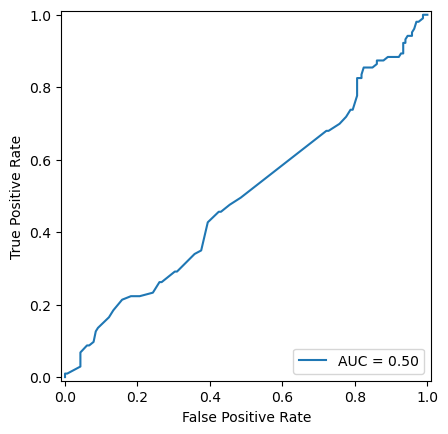

In [9]:
fpr, tpr, threshold = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc
).plot()

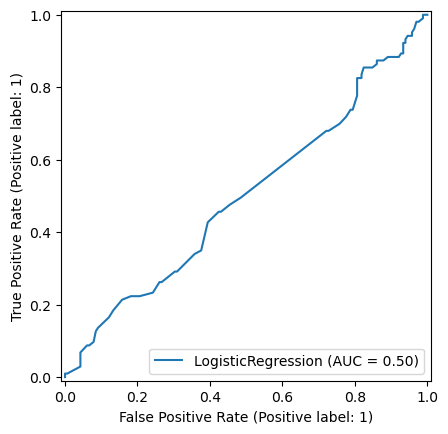

In [10]:
RocCurveDisplay.from_estimator(model, X_test, y_test)

#### You are likely to see that the model does not tend to predict that individuals survived the voyage. Let's see if we can determine why.

## 7. Look at the average age of survivors vs. those that did not survive the voyage. What do you find?

In [11]:
print(f'Survived Age Mean: {titanic_df[titanic_df['Survived'] == 1]['Age'].mean()}')
print(f'Not Survived Age Mean: {titanic_df[titanic_df['Survived'] == 0]['Age'].mean()}')

Survived Age Mean: 28.343689655172415
Not Survived Age Mean: 30.62617924528302


## 8. Perhaps the actual age number is not as important as whether a passenger was a child or an adult.
#### Create a Boolean column that indicates whether a passenger was a child or an adult. Pick a cutoff age and if they were less than this age, label as a child. We'll see later on how we can make choosing the age part of our model building pipeline, but for now, choose an age or do some calculations to pick an age that you think might do well.

In [12]:
# titanic_df[titanic_df['Age'] <= 18].groupby('Age')['Age'].count()

In [13]:
# titanic_df[titanic_df['Age'] <= 18].groupby('Age')['Survived'].sum()

In [14]:
child_age = 14

# titanic_df['Is_Child'] = [1 if age <= child_age else 0 for age in titanic_df['Age']] # This unwantedly fills NaN values
titanic_df.loc[titanic_df['Age'] <= child_age, 'Is_Child'] = True
titanic_df.loc[titanic_df['Age'] > child_age, 'Is_Child'] = False

In [15]:
titanic_df['Is_Child'].isna().sum()

np.int64(177)

## 9. When imputing the missing values, you'll need to change the strategy from mean to most_frequent.
#### Impute the missing values, then fit the model using this new variable, generate predictions, and view the confusion matrix. How did your model do?

### ANSWER: Somewhat better

In [16]:
features = ['Is_Child']
X = titanic_df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer = imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
confusion_matrix(
    y_true=y_test,
    y_pred=y_pred
)

array([[151,  14],
       [ 90,  13]])

#### Other common metrics for classification include accuracy, precision, and recall. For more information, see https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall. These metrics can be viewed using the [classification_report function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html). 

## 10. Generate a classification report for your model.

In [18]:
print(
    classification_report(
        y_true=y_test,
        y_pred=y_pred
    )
)

              precision    recall  f1-score   support

           0       0.63      0.92      0.74       165
           1       0.48      0.13      0.20       103

    accuracy                           0.61       268
   macro avg       0.55      0.52      0.47       268
weighted avg       0.57      0.61      0.53       268



#### Another important variable is the Sex variable. 

## 11. Create a DataFrame, X, which contains one column, Sex, and a Series, y, which contains the target variable.
#### Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split.

In [19]:
features = ['Sex']
X = titanic_df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

#### If you inspect the Sex variable, you'll find that it is encoded as a string. We need to convert it to a numeric type so that our model can use it. We can do this using a [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

## 12. Fit a OneHotEncoder to the training data and then transform both the training and test sets. Fit a model and evaluate the performance of this model.

### ANSWER: Much better than the previous models

In [20]:
enc = OneHotEncoder().fit(X_train)
X_train = enc.transform(X_train)
X_test = enc.transform(X_test)

In [21]:
model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix(
    y_true=y_test,
    y_pred=y_pred
)

array([[138,  27],
       [ 33,  70]])

In [22]:
print(
    classification_report(
        y_true=y_test,
        y_pred=y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       165
           1       0.72      0.68      0.70       103

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.78      0.77       268



#### Notice how we have used different types of transformations, an imputer for the age-related variables and a OneHotEncoder for the Sex variable. When we need to use multiple types of transformations, a [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) is useful. 

#### In the next part, we'll fit a model using both the Sex column and our column indicating whether the passenger was a child. 

## 13. Create a DataFrame, X, which contains two columns, Sex and the child indicator column, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable.
#### Make sure that you set a random_state during this split. Then create a ColumnTransformer which will apply a SimpleImputer to the child column and a OneHotEncoder to the Sex column. Fit it on the training data and then transform the test data. Then fit a model on this and see how well it does.

In [23]:
features = ['Sex', 'Is_Child']
X = titanic_df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

In [24]:
transformer = ColumnTransformer(
    transformers=[
        ('imputer', SimpleImputer(strategy='most_frequent'), ['Is_Child']),
        ('enc', OneHotEncoder(), ['Sex'])
    ],
    remainder='passthrough'
).fit(X_train)

X_train = transformer.transform(X_train)
X_test = transformer.transform(X_test)

In [25]:
model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix(
    y_true=y_test,
    y_pred=y_pred
)

array([[138,  27],
       [ 33,  70]])

In [26]:
print(
    classification_report(
        y_true=y_test,
        y_pred=y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       165
           1       0.72      0.68      0.70       103

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.78      0.77       268



#### Finally, let's see how we can do all of this in a slightly more compact manner. We can use a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) which allows us to specify preprocessing steps (like the ColumnTransformer we used earlier) as well as the model we want to fit. 

## 14. Create a Pipeline which contains the ColumnTransformer and the LogisticRegression model. 

In [27]:
features = ['Sex', 'Is_Child']
X = titanic_df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

In [28]:
pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', LogisticRegression())
]).fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

confusion_matrix(
    y_true=y_test,
    y_pred=y_pred
)

array([[138,  27],
       [ 33,  70]])

In [29]:
print(
    classification_report(
        y_true=y_test,
        y_pred=y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       165
           1       0.72      0.68      0.70       103

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.78      0.77       268



#### If you've reached this point, let your instructors know so that they can check in with you.

# Stretch Goals

## 1. Try adding additional features and see how this affects your model.
#### Think carefully about if you want passenger class to be treated as a numeric or a categorical variable.